Dataset: "Medical Cost Personal Dataset". This dataset contains
demographic data (age, sex, BMI, children, smoker, region) and the
corresponding medical insurance charges for individuals.

**Load the data and Inspect**

In [2]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Assignments/insurance.csv") # load your data
# check if data has loaded
display(df.head())
df.info()
print (df.shape)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
(1338, 7)


**Generate Descriptive statistics** ***
dataset has 1338 rows and 7 columns



In [3]:
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


**Data Cleaning**

In [4]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Assignments/insurance.csv") # load your data

# Find and print all instances of duplicated rows
print(df[df.duplicated(keep=False)])
print (df.duplicated().sum()) #Check for duplicates:
print(df.isnull().sum()) # Check Missing Value
# Total missing in whole dataset
df.isnull().sum().sum()

     age   sex    bmi  children smoker     region    charges
195   19  male  30.59         0     no  northwest  1639.5631
581   19  male  30.59         0     no  northwest  1639.5631
1
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


np.int64(0)

In [5]:
# Remove duplicates (keeps first occurrence)
df.drop_duplicates(inplace=True)
df.shape # check to confirm the row count went down.

(1337, 7)

save the cleaned data into a new csv file

In [6]:
df.to_csv('cleaned_insurance.csv', index=False) # Cleaned data saved to cleaned_insurance.csv
print('Cleaned data saved to cleaned_insurance.csv')

Cleaned data saved to cleaned_insurance.csv


** Encode Categorical Features into Numeric values for ML algorithm**

Categorical features 'sex' and 'smoker' will be label encoded as they are binary, and 'region' will be one-hot encoded to handle multiple categories without implying any order.

In [7]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Assuming df is already loaded and cleaned from previous steps
# If not, uncomment the line below to reload the data
df = pd.read_csv("/content/cleaned_insurance.csv")

# Create a copy to avoid SettingWithCopyWarning
df_encoded = df.copy()

# Label Encoding for 'sex' and 'smoker'
le = LabelEncoder()
df_encoded['sex'] = le.fit_transform(df_encoded['sex'])
df_encoded['smoker'] = le.fit_transform(df_encoded['smoker'])

# One-Hot Encoding for 'region'
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)


display(df_encoded.head())
df_encoded.info()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   sex               1337 non-null   int64  
 2   bmi               1337 non-null   float64
 3   children          1337 non-null   int64  
 4   smoker            1337 non-null   int64  
 5   charges           1337 non-null   float64
 6   region_northwest  1337 non-null   bool   
 7   region_southeast  1337 non-null   bool   
 8   region_southwest  1337 non-null   bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 66.7 KB


**Normalize the numerical features in the dataset using StandardScaler from sklearn.preprocessing. This will transform 'age', 'bmi', and 'charges' to have a mean of 0 and a standard deviation of 1, which is a common practice before training machine learning models.**

In [8]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features for scaling
numerical_cols = ['age', 'bmi', 'charges']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical features in df_encoded
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

# Display the head of the scaled DataFrame to verify
display(df_encoded.head())

# Display descriptive statistics of the scaled numerical columns to confirm scaling
display(df_encoded[numerical_cols].describe())

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,-1.440418,0,-0.453160,0,1,0.297857,False,False,True
1,-1.511647,1,0.509422,1,0,-0.954381,False,True,False
2,-0.799350,1,0.383155,3,0,-0.729373,False,True,False
3,-0.443201,1,-1.305052,0,0,0.719104,True,False,False
4,-0.514431,1,-0.292456,0,0,-0.777499,True,False,False


,age,bmi,charges
count,1.337000e+03,1.337000e+03,1.337000e+03
mean,-6.643070e-17,-2.285216e-16,-1.009747e-16
std,1.000374e+00,1.000374e+00,1.000374e+00
min,-1.511647e+00,-2.411119e+00,-1.004247e+00
25%,-8.705798e-01,-7.171725e-01,-7.048486e-01
50%,-1.582291e-02,-4.320166e-02,-3.215773e-01
75%,8.389340e-01,6.619260e-01,2.790883e-01
max,1.764921e+00,3.684136e+00,4.170826e+00


### Histogram of Charges
This histogram will show the distribution of medical charges. Given that the 'charges' column has been standardized, the histogram will reflect the distribution of the standardized values.

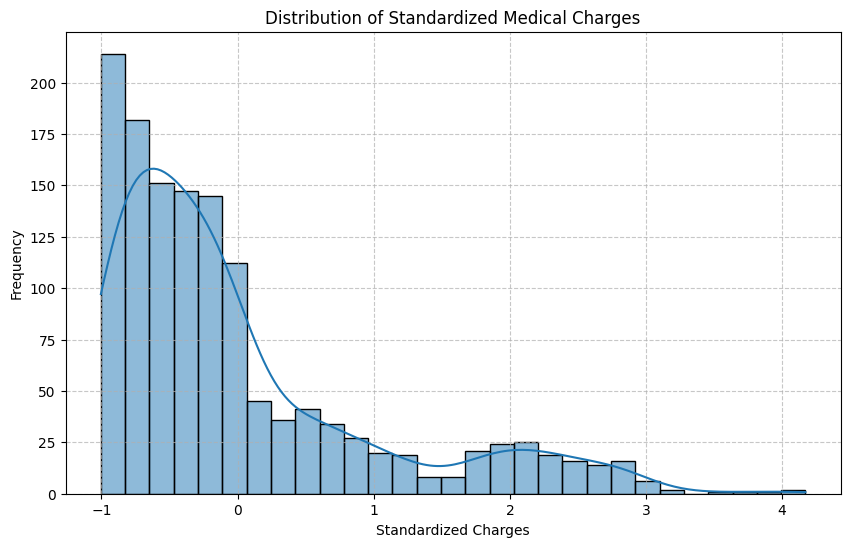

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_encoded['charges'], kde=True)
plt.title('Distribution of Standardized Medical Charges')
plt.xlabel('Standardized Charges')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Identifying the Outliers**

In [10]:
# Outliers for Non-Smokers
df_non_smokers = df_encoded[df_encoded['smoker'] == 0]

Q1_non_smokers = df_non_smokers['charges'].quantile(0.25)
Q3_non_smokers = df_non_smokers['charges'].quantile(0.75)
IQR_non_smokers = Q3_non_smokers - Q1_non_smokers

lower_bound_non_smokers = Q1_non_smokers - 1.5 * IQR_non_smokers
upper_bound_non_smokers = Q3_non_smokers + 1.5 * IQR_non_smokers

outliers_non_smokers = df_non_smokers[(df_non_smokers['charges'] < lower_bound_non_smokers) | (df_non_smokers['charges'] > upper_bound_non_smokers)]

print("\n--- Outliers for Non-Smokers ---")
print(f"Number of outliers in 'charges' for non-smokers: {len(outliers_non_smokers)}")
print(f"Lower bound for non-smoker outliers: {lower_bound_non_smokers:.2f}")
print(f"Upper bound for non-smoker outliers: {upper_bound_non_smokers:.2f}")
display(outliers_non_smokers)

# Outliers for Smokers
df_smokers = df_encoded[df_encoded['smoker'] == 1]

Q1_smokers = df_smokers['charges'].quantile(0.25)
Q3_smokers = df_smokers['charges'].quantile(0.75)
IQR_smokers = Q3_smokers - Q1_smokers

lower_bound_smokers = Q1_smokers - 1.5 * IQR_smokers
upper_bound_smokers = Q3_smokers + 1.5 * IQR_smokers

outliers_smokers = df_smokers[(df_smokers['charges'] < lower_bound_smokers) | (df_smokers['charges'] > upper_bound_smokers)]

print("\n--- Outliers for Smokers ---")
print(f"Number of outliers in 'charges' for smokers: {len(outliers_smokers)}")
print(f"Lower bound for smoker outliers: {lower_bound_smokers:.2f}")
print(f"Upper bound for smoker outliers: {upper_bound_smokers:.2f}")
display(outliers_smokers)


--- Outliers for Non-Smokers ---
Number of outliers in 'charges' for non-smokers: 46
Lower bound for non-smoker outliers: -1.68
Upper bound for non-smoker outliers: 0.76


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
9,1.480002,0,-0.790965,0,0,1.292271,True,False,False
62,1.764921,1,-0.977906,1,0,1.394989,True,False,False
115,1.480002,1,-0.339191,0,0,1.402702,False,False,False
138,1.052623,0,0.202773,3,0,1.160070,False,True,False
140,-0.371972,1,-1.351787,2,0,1.164462,False,False,False
219,-1.084269,0,-1.222241,0,0,0.974956,False,True,False
227,1.337542,0,1.844245,0,0,0.904375,False,True,False
242,1.123853,0,-0.633541,1,0,1.807477,False,False,True
245,1.052623,1,-0.105515,0,0,0.924956,True,False,False
289,0.910164,1,-0.699134,3,0,1.050213,False,True,False



--- Outliers for Smokers ---
Number of outliers in 'charges' for smokers: 0
Lower bound for smoker outliers: -1.88
Upper bound for smoker outliers: 4.79


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest


### Boxplot of Charges by Smoker/Non-Smoker

This boxplot will compare the distribution of standardized medical charges between smokers and non-smokers. This is particularly insightful as smoking is often a significant factor in health insurance costs.

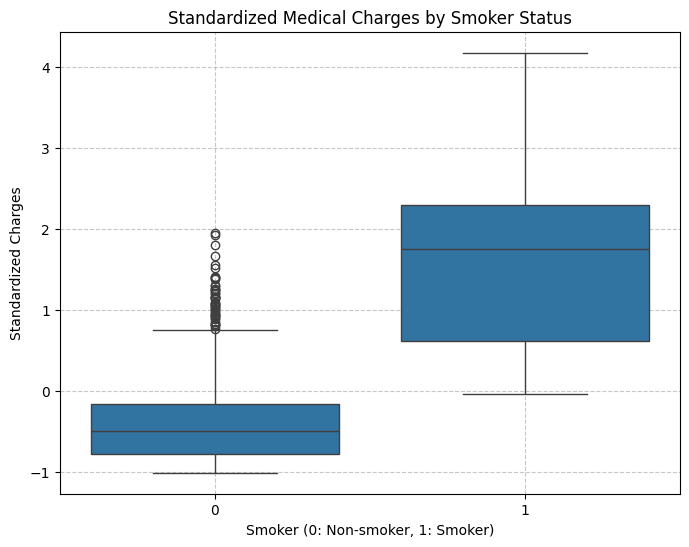

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='smoker', y='charges', data=df_encoded)
plt.title('Standardized Medical Charges by Smoker Status')
plt.xlabel('Smoker (0: Non-smoker, 1: Smoker)')
plt.ylabel('Standardized Charges')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Pair Plot to Observe Relationships

A pair plot will display pairwise relationships between all numerical features in the `df_encoded` DataFrame. This helps to identify trends, clusters, and correlations between different variables.

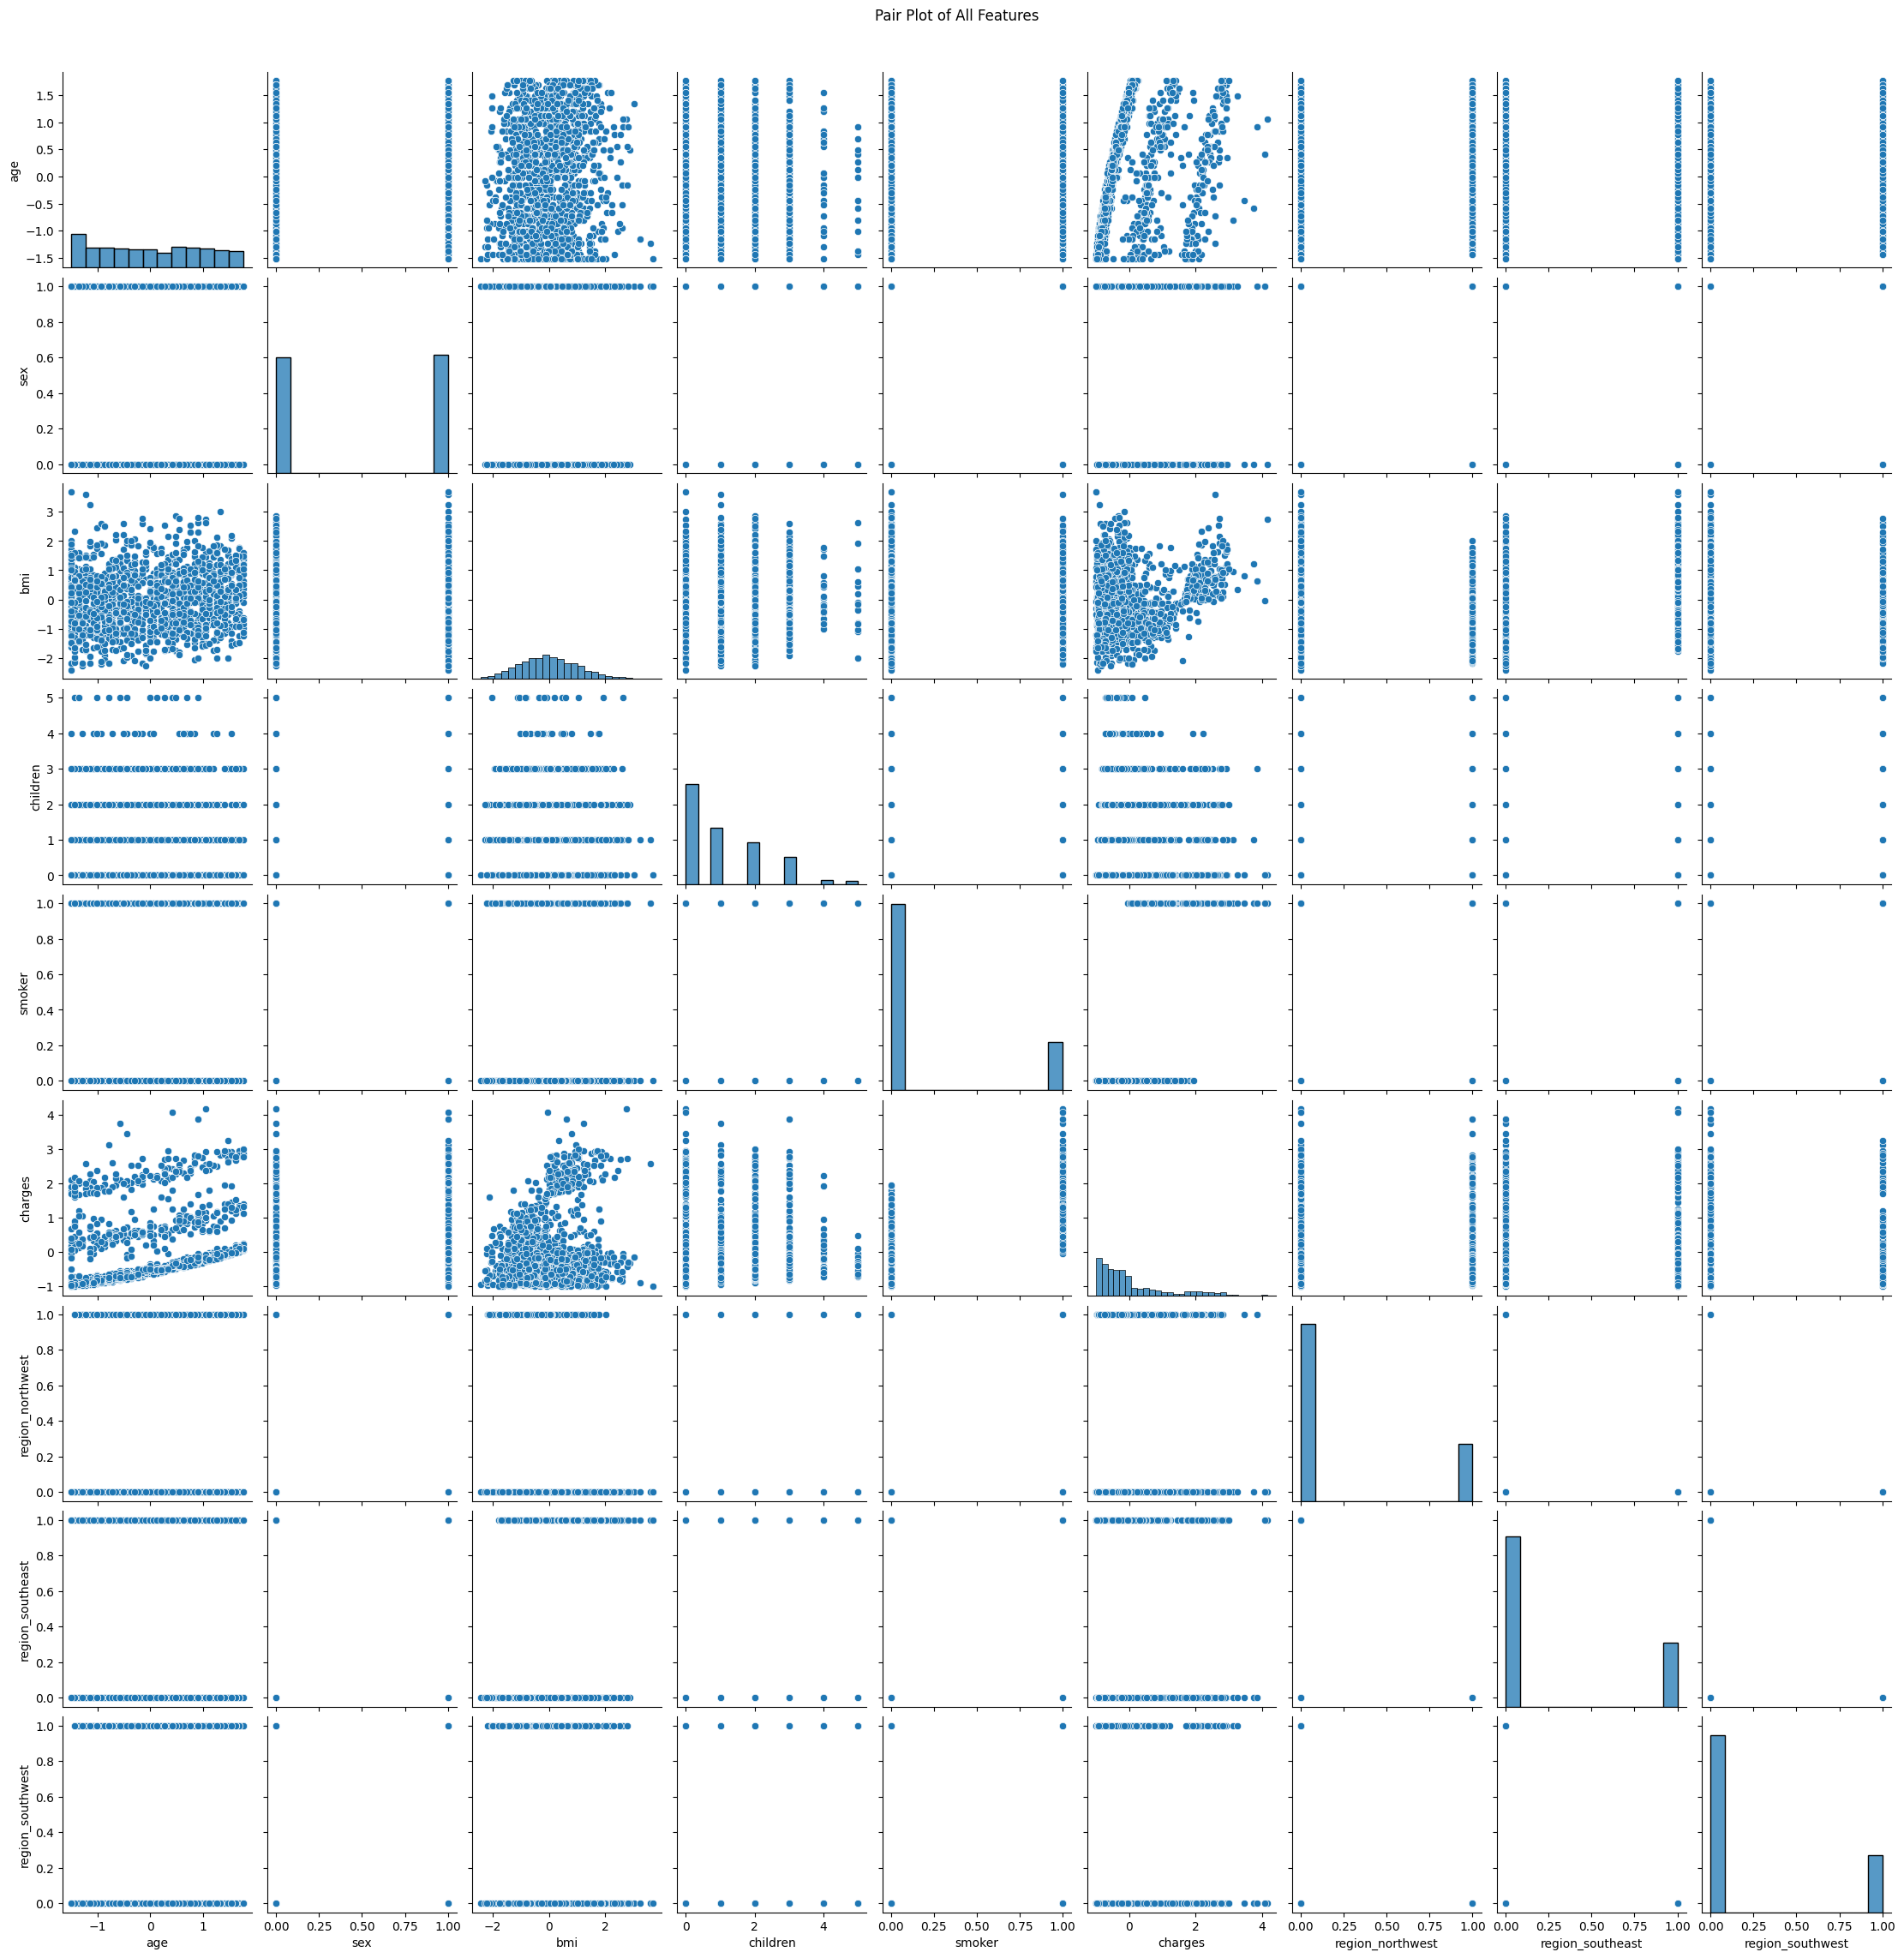

In [12]:
sns.pairplot(df_encoded)
plt.suptitle('Pair Plot of All Features', y=1.02) # Adjust suptitle position
plt.show()

### Check Correlations using a Heatmap

A heatmap will visualize the correlation matrix of the features. This allows for a quick understanding of how strongly each variable is related to every other variable, which can be useful for feature selection or understanding multicollinearity.

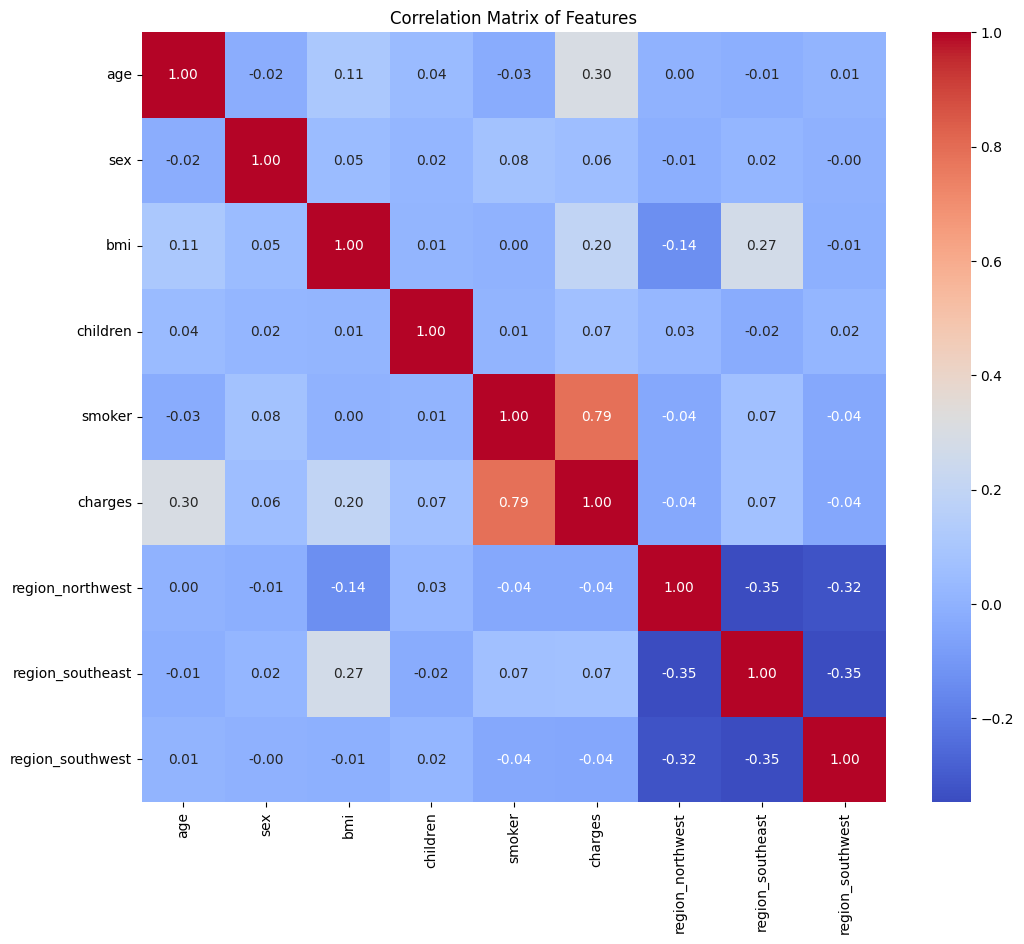

In [13]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

## Data Exploration Report

### 1. Data Overview and Quality
- The dataset contains 1337 unique entries after removing one duplicate row.
- There are no missing values in any of the columns, ensuring data completeness.
- Categorical features ('sex', 'smoker', 'region') were successfully encoded into numerical representations ('sex' and 'smoker' using label encoding, 'region' using one-hot encoding).
- Numerical features ('age', 'bmi', 'charges') were standardized, which is beneficial for many machine learning algorithms.

### 2. Descriptive Statistics & Distributions
- The average medical charge is approximately 13,270.42, with a wide standard deviation of 12,110.01, indicating significant variability in charges.
- The `charges` distribution, especially for non-smokers, shows a right-skew, with 46 outliers identified among non-smokers. No outliers were found among smokers after standardization.
- The boxplot clearly illustrates a substantial difference in medical charges between smokers and non-smokers, with smokers generally incurring much higher costs.

### 3. Relationships and Correlations
- The correlation heatmap reveals a strong positive correlation between being a `smoker` and `charges` (correlation coefficient of approximately 0.79).
- `age` and `bmi` also show moderate positive correlations with `charges`, suggesting that older individuals and those with higher BMI tend to have higher medical costs.
- `children`, `sex`, and `region` (after one-hot encoding) exhibit weaker correlations with `charges` compared to `smoker`, `age`, and `bmi`.

In [14]:
df.shape


(1337, 7)

## **Model Preparation**

Before training, we need to prepare the data by separating features (X) from the target variable (y), and then splitting the dataset into training and testing sets. **Typical split: 80% train / 20% test **
The 'charges' column will be our target/Dependent variable, and all other encoded features will be used as predictors.

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

# Re-create df_encoded because it was not found in the kernel's memory.
# This ensures the model preparation can proceed even if previous cells were not run
# or the kernel state was reset.

# 1. Load data and remove duplicates (as done in earlier cells)
df = pd.read_csv("/content/cleaned_insurance.csv")
df.drop_duplicates(inplace=True)

# 2. Create a copy for encoding
df_encoded = df.copy()

# 3. Label Encoding for 'sex' and 'smoker'
le = LabelEncoder()
df_encoded['sex'] = le.fit_transform(df_encoded['sex'])
df_encoded['smoker'] = le.fit_transform(df_encoded['smoker'])

# 4. One-Hot Encoding for 'region'
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

# 5. Scaling numerical features
numerical_cols = ['age', 'bmi', 'charges']
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

# Define features (X) and target (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Split the data into training and testing sets
# We'll use 80% for training and 20% for testing, with a fixed random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1069, 8)
X_test shape: (268, 8)
y_train shape: (1069,)
y_test shape: (268,)


##** Model Training**

We will train a Linear Regression model using the training data. Linear Regression is a fundamental supervised learning algorithm that models the linear relationship between the independent variables (features) and a dependent variable (target).

In [16]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
linear_reg_model = LinearRegression()

# Train the model using the training data
linear_reg_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print(f"Model coefficients: {linear_reg_model.coef_}")
print(f"Model intercept: {linear_reg_model.intercept_}")

Linear Regression model trained successfully.
Model coefficients: [ 0.28784892 -0.00838786  0.16054255  0.0440292   1.90633478 -0.03236139
 -0.06929881 -0.05444813]
Model intercept: -0.4017842785202782


## Model Evaluation

After training, it's crucial to evaluate the model's performance on unseen data (the test set). We will use several metrics to assess how well our Linear Regression model predicts medical charges:
- **R-squared (R2)**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables.
- **Mean Absolute Error (MAE)**: The average of the absolute differences between predictions and actual values.
- **Mean Squared Error (MSE)**: The average of the squared differences between predictions and actual values. It penalizes larger errors more.
- **Root Mean Squared Error (RMSE)**: The square root of MSE, providing an error metric in the same units as the target variable.


--- Model Evaluation ---
Mean Absolute Error (MAE): 0.3450
Mean Squared Error (MSE): 0.2421
Root Mean Squared Error (RMSE): 0.4920
R-squared (R2): 0.8069


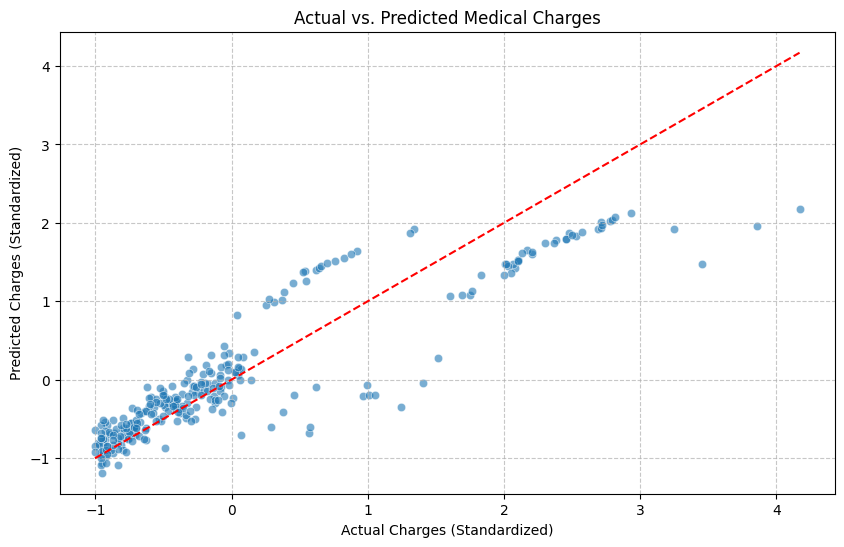

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = linear_reg_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

# Visualize actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--') # Perfect prediction line
plt.title('Actual vs. Predicted Medical Charges')
plt.xlabel('Actual Charges (Standardized)')
plt.ylabel('Predicted Charges (Standardized)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Residual Analysis

To check for patterns or heteroscedasticity (non-constant variance of errors), we will analyze the residuals. Residuals are the differences between the observed and predicted values. In a good linear regression model, residuals should be randomly scattered around zero with no discernible pattern, and their variance should be constant across all predicted values.

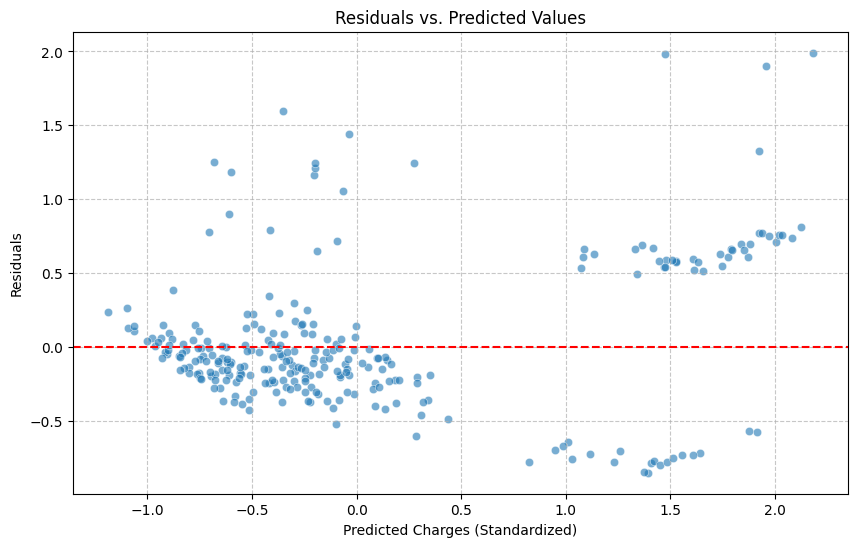

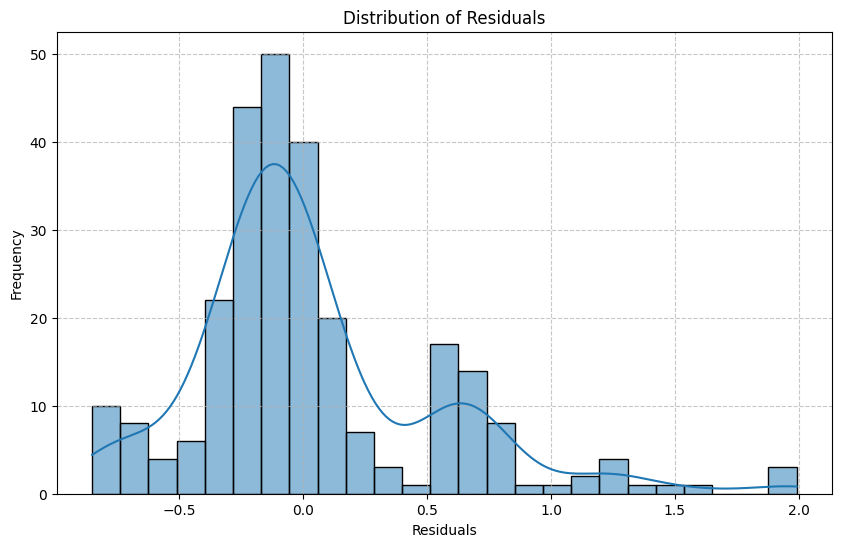

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression

# Re-create df_encoded, X_train, X_test, y_train, y_test, linear_reg_model, and y_pred
# to ensure variables are defined for residual analysis.

# 1. Load data and remove duplicates
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Assignments/insurance.csv")
df.drop_duplicates(inplace=True)

# 2. Create a copy for encoding
df_encoded = df.copy()

# 3. Label Encoding for 'sex' and 'smoker'
le = LabelEncoder()
df_encoded['sex'] = le.fit_transform(df_encoded['sex'])
df_encoded['smoker'] = le.fit_transform(df_encoded['smoker'])

# 4. One-Hot Encoding for 'region'
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

# 5. Scaling numerical features
numerical_cols = ['age', 'bmi', 'charges']
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

# Define features (X) and target (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = linear_reg_model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

# Plot residuals against predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Charges (Standardized)')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Plot a histogram of the residuals to check for normality
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()